# Notebook 4: Plots and tables (v4, final)

Three plots, main-text target = `is_active_not_toxic` throughout (pre-committed a priori - the
paper's own confound-controlled headline target - to avoid picking whichever target makes each
plot look best). Plot 3 is the one exception, since comparing across targets is its actual subject.

- **Plot 1**: CLOOME/CellCLIP train -> validation -> test on BBBC036v1's official split - the
  sharpest direct evidence of pretraining-boundary leakage.
- **Plot 2**: representation ranking on clean evaluations (BBBC036v1 official, JUMP-CP chemical,
  JUMP-CP plate) - CLOOME is weakest throughout, including vs. its own untrained architecture.
- **Plot 3**: task difficulty across all 6 representations - `active, not toxic` is the hardest
  target almost everywhere, not just for CLOOME/CellCLIP.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assumes the notebook runs with its own directory (chemical_surrogate_study/notebooks/) as the
# working directory, which is Jupyter's default when opening a notebook.
NOTEBOOKS_DIR = Path.cwd()
STUDY_DIR = NOTEBOOKS_DIR.parent if NOTEBOOKS_DIR.name == "notebooks" else NOTEBOOKS_DIR
sys.path.insert(0, str(STUDY_DIR))
from aime_style import AIME_PALETTE, AIME_RCPARAMS, add_panel_label, DEEP_TEAL, ROYAL_PURPLE, SOFT_LAVENDER, FOREST_GREEN, MUTED_PLUM, DARK_SLATE

plt.rcParams.update(AIME_RCPARAMS)

RESULTS_DIR = STUDY_DIR / "results"
FIG_DIR = STUDY_DIR / "figures"
TABLE_DIR = STUDY_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_TARGET = "is_active_not_toxic"
TARGETS = ["is_active", "is_active_and_toxic", "is_active_not_toxic"]
TARGET_LABELS = {"is_active": "active", "is_active_and_toxic": "active & toxic", "is_active_not_toxic": "active, not toxic"}

STRUCTURE_REPR_ORDER = ["PhysChem", "LogP", "MorganFP", "CellCLIP", "CLOOME", "MLP"]
REPR_COLORS = {
    "PhysChem": DEEP_TEAL, "CellCLIP": ROYAL_PURPLE, "LogP": SOFT_LAVENDER,
    "MorganFP": FOREST_GREEN, "CLOOME": MUTED_PLUM, "MLP": DARK_SLATE, "Morphology": "#999999",
}
RENAME = {"MLP_CLOOME_arch": "MLP"}

## Load results

In [2]:
bbbc_cv = pd.read_csv(RESULTS_DIR / "bbbc036v1" / "cv_scores.csv").replace({"representation": RENAME})
bbbc_official = pd.read_csv(RESULTS_DIR / "bbbc036v1" / "official_split_results.csv").replace({"representation": RENAME})
bbbc_train_val_test = pd.read_csv(RESULTS_DIR / "bbbc036v1" / "official_split_train_val_test.csv").replace({"representation": RENAME})
jump_cv = pd.read_csv(RESULTS_DIR / "jumpcp" / "cv_scores.csv").replace({"representation": RENAME})


def cv_mean_ci(cv_df, split_type, target, representation):
    sub = cv_df[(cv_df.split_type == split_type) & (cv_df.target == target) & (cv_df.representation == representation)]
    n = len(sub)
    m, s = sub["auc"].mean(), sub["auc"].std(ddof=1)
    se = s / np.sqrt(n)
    return m, m - 1.96 * se, m + 1.96 * se


def official_mean_ci(official_df, target, representation):
    row = official_df[(official_df.target == target) & (official_df.representation == representation)].iloc[0]
    return row["test_auc"], row["test_auc_ci_lo"], row["test_auc_ci_hi"]


print("Loaded.")

Loaded.


## Plot 1: The leakage signature - train, validation, test on the official split

Target: `active, not toxic`. If CLOOME/CellCLIP's frozen embedding is more separable for compounds
seen during their own pretraining than for genuinely novel ones, the train AUROC should be far
above validation/test, well beyond ordinary regularized-model optimism (PhysChem's reference gap).

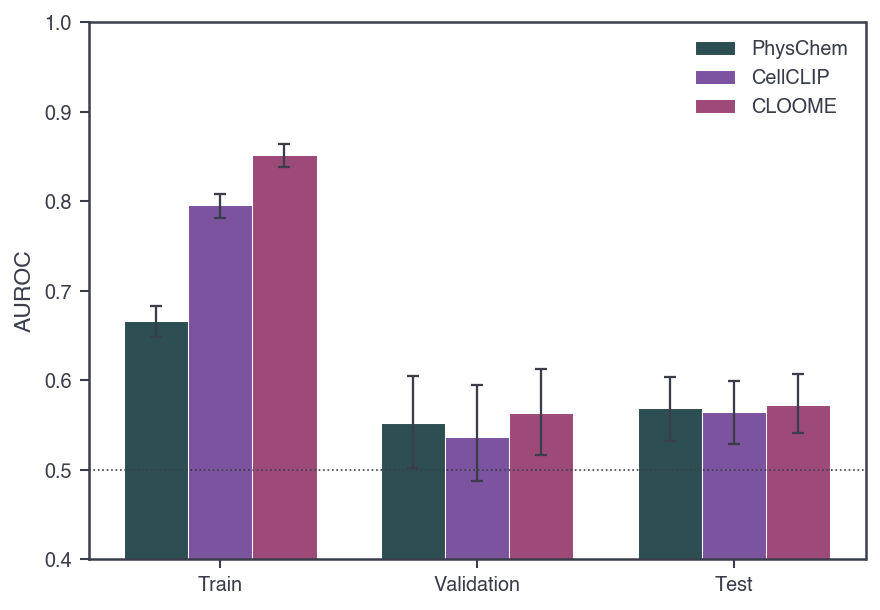

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2))
regimes = ["Train", "Validation", "Test"]
x = np.arange(3)
w = 0.25
for i, r in enumerate(["PhysChem", "CellCLIP", "CLOOME"]):
    row = bbbc_train_val_test[(bbbc_train_val_test.target == MAIN_TARGET) & (bbbc_train_val_test.representation == r)].iloc[0]
    means = np.array([row["train_auc"], row["val_auc"], row["test_auc"]])
    los = np.array([row["train_ci_lo"], row["val_ci_lo"], row["test_ci_lo"]])
    his = np.array([row["train_ci_hi"], row["val_ci_hi"], row["test_ci_hi"]])
    yerr = [means - los, his - means]
    xpos = x + (i - 1) * w
    ax.bar(xpos, means, width=w, color=REPR_COLORS[r], label=r, edgecolor="white", linewidth=0.5)
    ax.errorbar(xpos, means, yerr=yerr, fmt="none", ecolor=DARK_SLATE, elinewidth=1.1, capsize=3, capthick=1.1)
ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.set_ylabel("AUROC")
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color=DARK_SLATE, linestyle=":", linewidth=0.8)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "plot1_leakage_train_val_test.png")
fig.savefig(FIG_DIR / "plot1_leakage_train_val_test.pdf")
plt.show()

## Plot 2: Representation ranking on clean evaluations

Target: `active, not toxic`. Three panels. Panel (a) (BBBC036v1 official split) excludes
CLOOME/CellCLIP - their standing on this split is already the full subject of Plot 1, so repeating
it here would be redundant; this panel instead shows how the non-pretrained representations compare
to each other. Panels (b)-(c) (JUMP-CP chemical/plate) include all 6, since that comparison isn't
shown anywhere else. All bars have 95% CI.

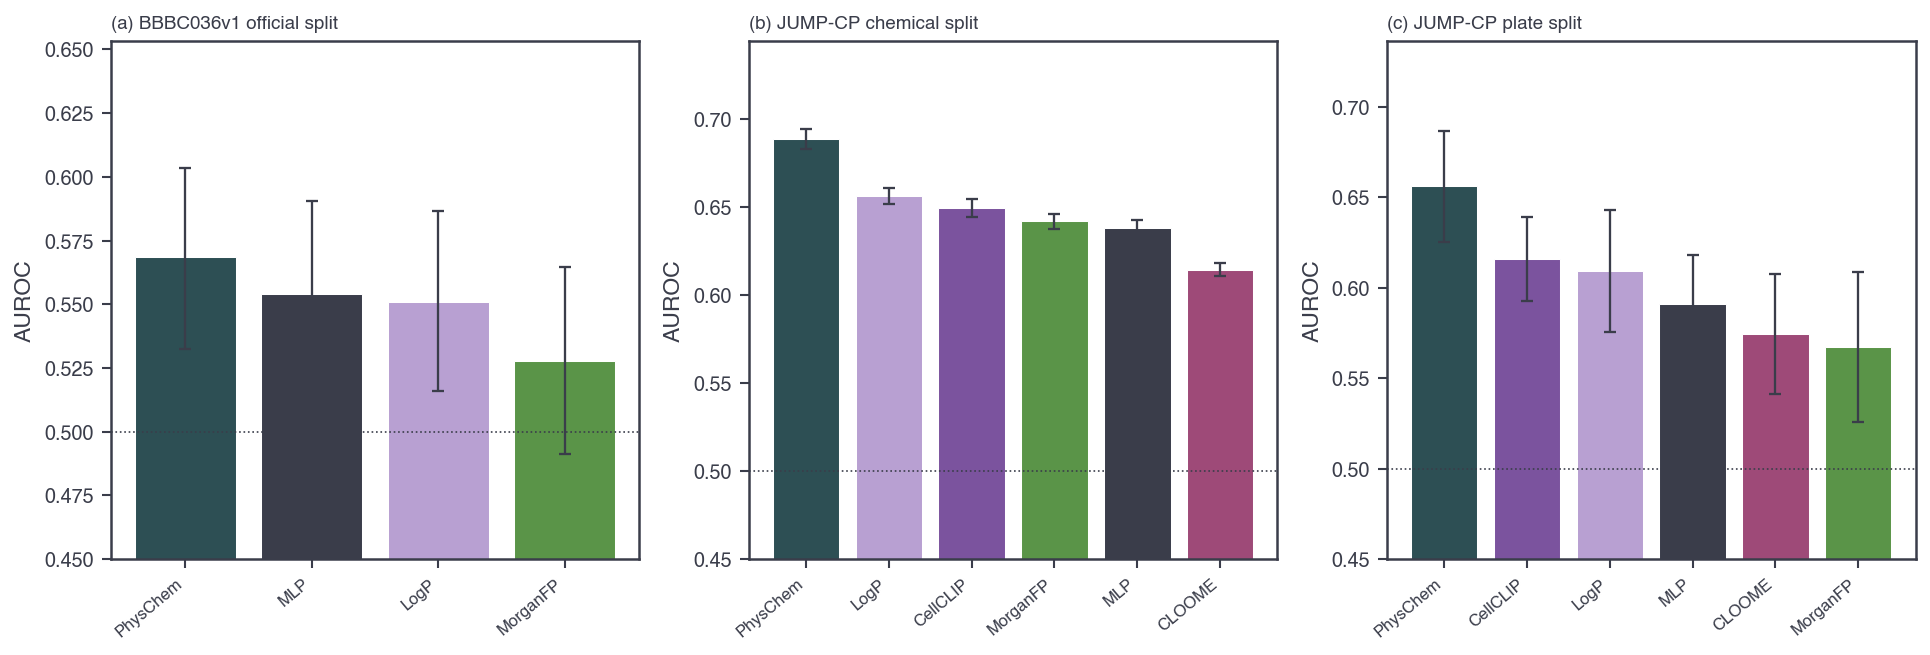

In [4]:
def ranking_panel(ax, means_los_his, title):
    order = sorted(means_los_his, key=lambda r: means_los_his[r][0], reverse=True)
    x = np.arange(len(order))
    vals = np.array([means_los_his[r][0] for r in order])
    los = np.array([means_los_his[r][1] for r in order])
    his = np.array([means_los_his[r][2] for r in order])
    colors = [REPR_COLORS[r] for r in order]
    ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.errorbar(x, vals, yerr=[vals - los, his - vals], fmt="none", ecolor=DARK_SLATE, elinewidth=1.1, capsize=3, capthick=1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("AUROC")
    ax.set_ylim(0.45, max(his) + 0.05)
    ax.axhline(0.5, color=DARK_SLATE, linestyle=":", linewidth=0.8)
    ax.set_title(title, fontsize=9, color=DARK_SLATE, loc="left")


NON_PRETRAINED = ["PhysChem", "LogP", "MorganFP", "MLP"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

means_bbbc = {r: official_mean_ci(bbbc_official, MAIN_TARGET, r) for r in NON_PRETRAINED}
ranking_panel(axes[0], means_bbbc, "(a) BBBC036v1 official split")

means_jc = {r: cv_mean_ci(jump_cv, "chemical", MAIN_TARGET, r) for r in STRUCTURE_REPR_ORDER}
ranking_panel(axes[1], means_jc, "(b) JUMP-CP chemical split")

means_jp = {r: cv_mean_ci(jump_cv, "plate", MAIN_TARGET, r) for r in STRUCTURE_REPR_ORDER}
ranking_panel(axes[2], means_jp, "(c) JUMP-CP plate split")

fig.tight_layout()
fig.savefig(FIG_DIR / "plot2_representation_ranking.png")
fig.savefig(FIG_DIR / "plot2_representation_ranking.pdf")
plt.show()

## Plot 3: Task difficulty across representations

All 6 representations, all 3 targets, two panels (BBBC036v1 official, JUMP-CP chemical).
`active, not toxic` is the hardest target for 6/6 representations on BBBC036v1 and 4/6 on JUMP-CP
(LogP and CLOOME are the exceptions there, where `active & toxic` is even harder) - shown, not
rounded up to a universal claim.

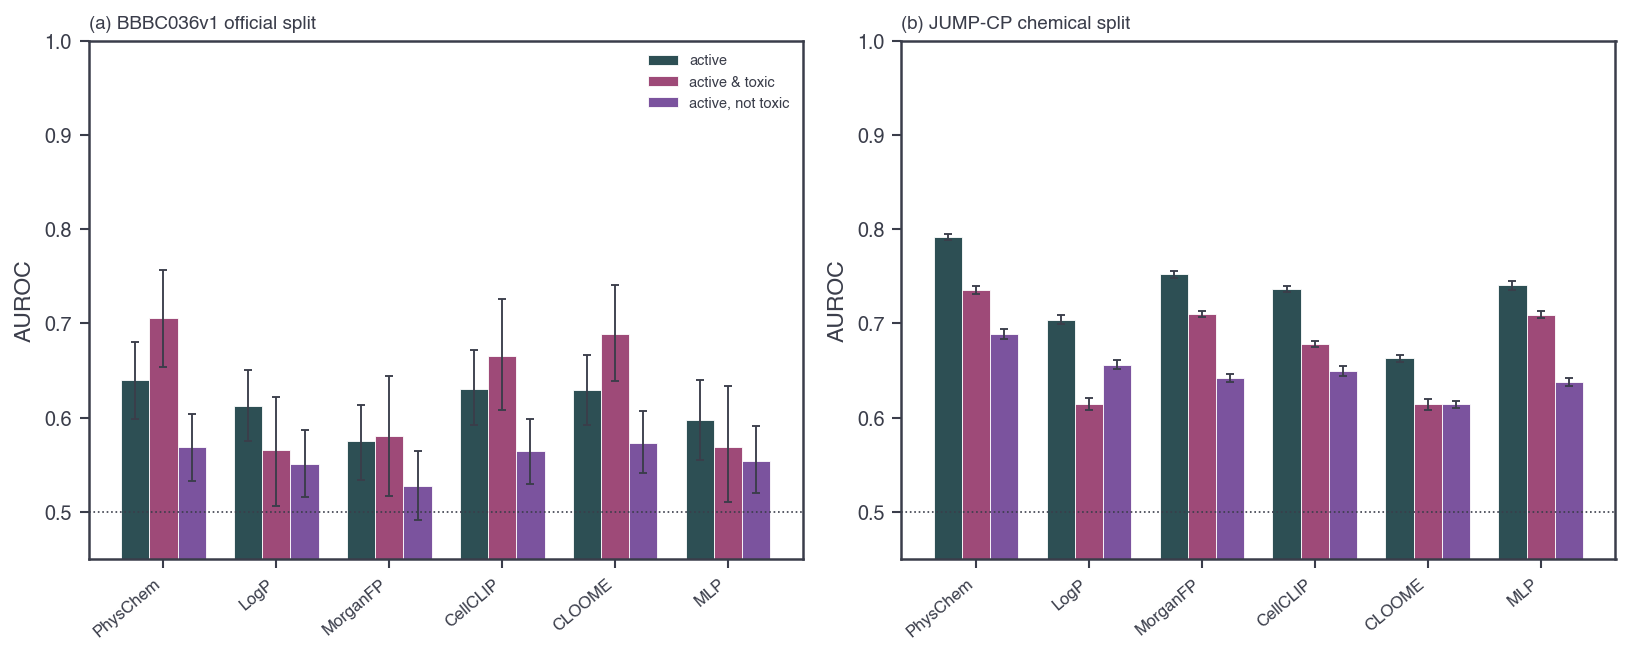

In [5]:
def task_difficulty_panel(ax, means_los_his_by_target, title):
    x = np.arange(len(STRUCTURE_REPR_ORDER))
    w = 0.25
    for i, target in enumerate(TARGETS):
        vals = np.array([means_los_his_by_target[target][r][0] for r in STRUCTURE_REPR_ORDER])
        los = np.array([means_los_his_by_target[target][r][1] for r in STRUCTURE_REPR_ORDER])
        his = np.array([means_los_his_by_target[target][r][2] for r in STRUCTURE_REPR_ORDER])
        color = [DEEP_TEAL, MUTED_PLUM, ROYAL_PURPLE][i]
        xpos = x + (i - 1) * w
        ax.bar(xpos, vals, width=w, color=color, label=TARGET_LABELS[target], edgecolor="white", linewidth=0.4)
        ax.errorbar(xpos, vals, yerr=[vals - los, his - vals], fmt="none", ecolor=DARK_SLATE, elinewidth=0.9, capsize=2, capthick=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(STRUCTURE_REPR_ORDER, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("AUROC")
    ax.set_ylim(0.45, 1.0)
    ax.axhline(0.5, color=DARK_SLATE, linestyle=":", linewidth=0.8)
    ax.set_title(title, fontsize=9, color=DARK_SLATE, loc="left")


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

means_bbbc_by_target = {t: {r: official_mean_ci(bbbc_official, t, r) for r in STRUCTURE_REPR_ORDER} for t in TARGETS}
task_difficulty_panel(axes[0], means_bbbc_by_target, "(a) BBBC036v1 official split")
axes[0].legend(fontsize=7, loc="upper right")

means_jump_by_target = {t: {r: cv_mean_ci(jump_cv, "chemical", t, r) for r in STRUCTURE_REPR_ORDER} for t in TARGETS}
task_difficulty_panel(axes[1], means_jump_by_target, "(b) JUMP-CP chemical split")

fig.tight_layout()
fig.savefig(FIG_DIR / "plot3_task_difficulty.png")
fig.savefig(FIG_DIR / "plot3_task_difficulty.pdf")
plt.show()

## Table 1: consolidated reference (trustworthy numbers only)

In [6]:
def fmt_official(target, representation):
    m, lo, hi = official_mean_ci(bbbc_official, target, representation)
    return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"


def fmt_cv(cv_df, target, representation):
    m, lo, hi = cv_mean_ci(cv_df, "chemical", target, representation)
    return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"


all_reps = ["Morphology"] + STRUCTURE_REPR_ORDER
rows = []
for r in all_reps:
    row = {"representation": r}
    for t in TARGETS:
        row[f"BBBC036v1 official ({TARGET_LABELS[t]})"] = fmt_official(t, r)
        row[f"JUMP-CP chemical CV ({TARGET_LABELS[t]})"] = fmt_cv(jump_cv, t, r)
    rows.append(row)
table1 = pd.DataFrame(rows).set_index("representation")
print(table1.to_string())

latex1 = table1.to_latex(escape=True, column_format="l" + "c" * len(table1.columns))
(TABLE_DIR / "table1_consolidated.tex").write_text(latex1)
table1.to_csv(RESULTS_DIR / "table1_consolidated.csv")
print(f"\nSaved -> tables/table1_consolidated.tex")

               BBBC036v1 official (active) JUMP-CP chemical CV (active) BBBC036v1 official (active & toxic) JUMP-CP chemical CV (active & toxic) BBBC036v1 official (active, not toxic) JUMP-CP chemical CV (active, not toxic)
representation                                                                                                                                                                                                                 
Morphology            0.773 [0.744, 0.800]         0.937 [0.936, 0.939]                0.950 [0.917, 0.975]                 0.977 [0.977, 0.978]                   0.764 [0.734, 0.793]                    0.848 [0.846, 0.851]
PhysChem              0.640 [0.599, 0.680]         0.792 [0.789, 0.795]                0.706 [0.654, 0.757]                 0.736 [0.732, 0.740]                   0.568 [0.532, 0.603]                    0.689 [0.683, 0.694]
LogP                  0.612 [0.575, 0.651]         0.704 [0.699, 0.709]                0.565 [0.506, 0.6

## Done

In [7]:
print("Notebook 4 (v4, final) complete. Figures in", FIG_DIR, "- table in", TABLE_DIR)

Notebook 4 (v4, final) complete. Figures in /Users/telio/chemical-surrogate-limits/chemical_surrogate_study/figures - table in /Users/telio/chemical-surrogate-limits/chemical_surrogate_study/tables
